In [2]:
import numpy as np
from gpflow.kernels import RBF
import matplotlib.pyplot as plt

82] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-01 18:16:53.430233: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2.9999999999999996


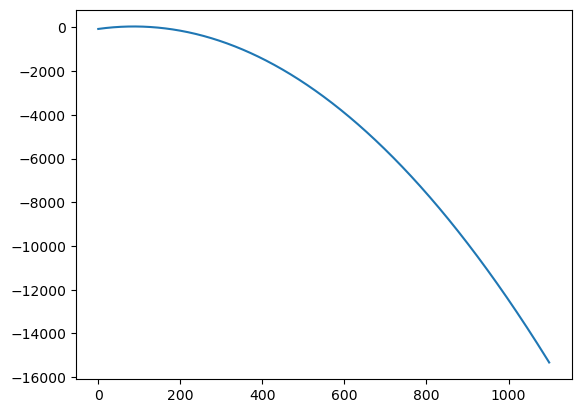

In [43]:
# N(x|mu, sigma) -> h(x) = -1/2 log 2pi + 1/2 det(sigma) + n/2

def multivariate_entropy(mu, sigma):
    n = len(mu)
    return -n/2 * np.log(2*np.pi) + 0.5 * np.linalg.det(sigma) + n/2

kernel = RBF()
X = np.linspace(0, 10, 100).reshape(-1, 1)
covariance = np.ones((2, 2)) + np.diag([1, 1])

print(np.linalg.det(covariance))

cs = []
for i in np.arange(-10, 100, 0.1):
    cs.append(np.log(np.linalg.det(covariance)) - multivariate_entropy(np.zeros_like(X), covariance*i) - np.trace(covariance*i))

plt.plot(cs)